In [504]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


plt.rcParams['font.sans-serif'] = ['SimHei']  # 例如使用黑体（SimHei），如果没有此字体可使用其他中文字体
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题

美国社会保障管理局（SSA）提供了一份从1880年到现在的婴儿名字频率数据。HadleyWickham（多款流行R包的作者）经常用这份数据来演示R的数据处理功能。

本题数据展示：  

![jupyter](13.4.png)  

![jupyter](13.5.png)

我们要做一些数据规整才能加载这个数据集，完成规整后会得到一个如下的DataFrame：

In [506]:
# 按行读取，不转行
with open("../datasets/babynames/yob1880.txt") as f:
    # names = pd.read_csv(f, names=["Name", "Gender", "Count"])
    lines = f.readlines()  # 读取所有行
    print(lines[:5])

['Mary,F,7065\n', 'Anna,F,2604\n', 'Emma,F,2003\n', 'Elizabeth,F,1939\n', 'Minnie,F,1746\n']


In [508]:
# 转行写法
with open("../datasets/babynames/yob1880.txt") as f:
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())

Mary,F,7065
Anna,F,2604
Emma,F,2003
Elizabeth,F,1939
Minnie,F,1746


In [510]:
# DF 写法
with open("../datasets/babynames/yob1880.txt") as f:
    names = pd.read_csv(f, names=["Name", "Gender", "Count"])

names.head()

,Name,Gender,Count
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746


可以用这个数据集做很多事，例如：  
根据给定名字，对该名字随时间的比例进行可视化。  
确定某个名字的相对排名。  
判断各年度最流行的名字，或者流行程度增长或减少最多的名字。  
分析名字趋势：元音、辅音、长度、总体多样性、拼写变化、首尾字母等。  
分析外源性趋势：圣经中的名字、名人、人口结构变化等。  

在写作本书时，美国社会保障管理局将该数据库按年度制成了多个数据文件，其中给出了每个性别/名字组合的出生总数。读者可以下载原始档案（http:/www.ssa.gov/oact/babynames/limits.html)

In [512]:
# csv转化为 DF
# 姓名、性别、出生人数
names1880 = pd.read_csv("../datasets/babynames/yob1880.txt", names=["name", "sex", "births"])

names1880

,name,sex,births
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939
4,Minnie,F,1746
...,...,...,...
1995,Woodie,M,5
1996,Worthy,M,5
1997,Wright,M,5
1998,York,M,5


这些文件中仅含有当年出现超过5次的名字。  
为了简单起见，可以用按性别列出的,出生总和作为该年度的出生总数：

In [514]:
names1880.groupby("sex")["births"].sum()

sex
F     90993
M    110493
Name: births, dtype: int64

由于该数据集按年度分成了多个文件，因此第一件事情就是将所有数据都组装到一个DataFrame中，并加上一个字段year。**使用pandas.concat即可完成。**

In [516]:
pieces = []
for year in range(1880, 2011):
    path = f"../datasets/babynames/yob{year}.txt"
    frame = pd.read_csv(path, names=["name", "sex", "births"])

    # 添加年份一列
    frame["year"] = year
    pieces.append(frame)

# 将多个DF进行拼接时，不保留原来的索引，重新生成一个连续的整数索引
names = pd.concat(pieces, ignore_index=True)  

names

,name,sex,births,year
0,Mary,F,7065,1880
1,Anna,F,2604,1880
2,Emma,F,2003,1880
3,Elizabeth,F,1939,1880
4,Minnie,F,1746,1880
...,...,...,...,...
1690779,Zymaire,M,5,2010
1690780,Zyonne,M,5,2010
1690781,Zyquarius,M,5,2010
1690782,Zyran,M,5,2010


ignore_index=True 不保留索引  
保留索引：  
一共也是170w条数据，但是每个DF的索引都保留了，所以最后才是3.3w条  

![jupyter](13.6.png) 


concat 和 merge 区别

![jupyter](13.7.png) 

In [420]:
# 有了这些数据之后，我们就可以利用groupby或pivot_table在年和性别层级上对其进行聚合
total_births = names.pivot_table("births", index="year",
                                 columns="sex", aggfunc=sum)

total_births.tail()

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17552\3394702356.py:2: FutureWarning: The provided callable <built-in function sum> is currently using DataFrameGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  total_births = names.pivot_table("births", index="year",


sex,F,M
year,,
2006,1896468,2050234
2007,1916888,2069242
2008,1883645,2032310
2009,1827643,1973359
2010,1759010,1898382


这个警告信息是提醒，在未来的 pandas 版本中，pivot_table 或 groupby 操作中处理可调用对象（如 sum 函数）的方式会发生变化。具体来说，当你传递一个可调用对象时，pandas 不再使用其内部方法（DataFrameGroupBy.sum），而是会直接使用你传递的可调用对象。

为了保持当前的行为，你可以将可调用对象 sum 替换为字符串 "sum"。以下是你可以调整代码的方式：

In [518]:
total_births = names.pivot_table("births", index="year",
                                 columns="sex", aggfunc="sum")

total_births.tail()

sex,F,M
year,,
2006,1896468,2050234
2007,1916888,2069242
2008,1883645,2032310
2009,1827643,1973359
2010,1759010,1898382


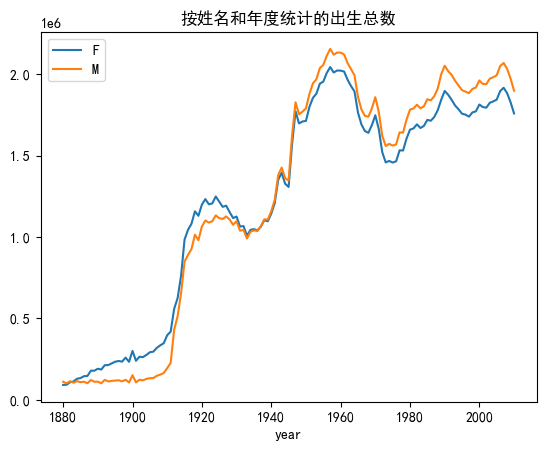

In [520]:
total_births.plot(title="按姓名和年度统计的出生总数")

plt.legend()

plt.show()

插入一个列 prop， 用于存放指定的婴儿数相对于出生总数的比例。  
若prop值为0.02，表示每100名婴儿中有2名取了当前这个名字。

In [354]:
# 先按年和性别分组，然后再将这个新列添加到各个分组上：
# 计算每组内每个元素的比例
def add_prop(group):
    group["prop"] = group["births"] / group["births"].sum()  # 每个姓名的婴儿出生数除以出生总数
    return group  # 返回修改后的分组数据，包括新添加的prop

names = names.groupby(["year", "sex"]).apply(add_prop)  # 按指定列分组并应用函数

names

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17552\3680349794.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(["year", "sex"]).apply(add_prop)  # 按指定列分组并应用函数


name sex  births  year      prop
year sex                                               
1880 F   0             Mary   F    7065  1880  0.077643
         1             Anna   F    2604  1880  0.028618
         2             Emma   F    2003  1880  0.022013
         3        Elizabeth   F    1939  1880  0.021309
         4           Minnie   F    1746  1880  0.019188
...                     ...  ..     ...   ...       ...
2010 M   1690779    Zymaire   M       5  2010  0.000003
         1690780     Zyonne   M       5  2010  0.000003
         1690781  Zyquarius   M       5  2010  0.000003
         1690782      Zyran   M       5  2010  0.000003
         1690783      Zzyzx   M       5  2010  0.000003

[1690784 rows x 5 columns]

这个警告，当前版本的 pandas 中，DataFrameGroupBy.apply 操作会同时作用于分组列（即 groupby 时指定的列，比如 year 和 sex）。但是，在未来的 pandas 版本中，这种行为会发生变化，默认情况下，分组列将被排除在 apply 操作之外。  

你看到的警告建议：  

你可以通过传递 include_groups=False 参数，显式地排除分组列，不让它们参与 apply 操作。  
或者在 groupby 之后，显式选择分组列以保持当前行为，避免将来的行为变化影响结果。  

In [279]:
# 先按年和性别分组，然后再将这个新列添加到各个分组上：
# 计算每组内每个元素的比例
def add_prop(group):
    group["prop"] = group["births"] / group["births"].sum()  # 每个姓名的婴儿出生数除以出生总数
    return group  # 返回修改后的分组数据，包括新添加的prop

names = names.groupby(["year", "sex"]).apply(add_prop, include_groups=False)  # 按指定列分组并应用函数

names 

name  births      prop
year sex                                     
1880 F   0             Mary    7065  0.077643
         1             Anna    2604  0.028618
         2             Emma    2003  0.022013
         3        Elizabeth    1939  0.021309
         4           Minnie    1746  0.019188
...                     ...     ...       ...
2010 M   1690779    Zymaire       5  0.000003
         1690780     Zyonne       5  0.000003
         1690781  Zyquarius       5  0.000003
         1690782      Zyran       5  0.000003
         1690783      Zzyzx       5  0.000003

[1690784 rows x 3 columns]

**为什么sex、year列没了？**  

**include_groups=False**，这句代码让分组键排除在结果之外，只是当作分组键使用，即当作组合索引使用，一般都默认为false  

**group_keys=False**，这句代码它的作用是控制在 apply 函数中，是否将分组键（year 和 sex）作为结果的一部分。



默认是True当作结果保存在结果列中并且生成多级索引在最前列，False的话就是不会生成多级索引，而是分组保持普通列输出。



书中默认的就是不追加多层索引的例子

**这个第三种写法才是最贴切书中的源代码**

In [427]:
# 先按年和性别分组，然后再将这个新列添加到各个分组上：
# 计算每组内每个元素的比例
def add_prop(group):
    group["prop"] = group["births"] / group["births"].sum()  # 每个姓名的婴儿出生数除以出生总数
    return group  # 返回修改后的分组数据，包括新添加的prop

names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop)  # 按指定列分组并应用函数

names

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17552\4254840016.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop)  # 按指定列分组并应用函数


,name,sex,births,year,prop
0,Mary,F,7065,1880,0.077643
1,Anna,F,2604,1880,0.028618
2,Emma,F,2003,1880,0.022013
3,Elizabeth,F,1939,1880,0.021309
4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...
1690779,Zymaire,M,5,2010,0.000003
1690780,Zyonne,M,5,2010,0.000003
1690781,Zyquarius,M,5,2010,0.000003
1690782,Zyran,M,5,2010,0.000003


**第四种写法**  
用reset_index()将索引转化为列，最完整写法

In [522]:
def add_prop(group):
    group["prop"] = group["births"] / group["births"].sum()  # 每个姓名的婴儿出生数除以出生总数
    return group  # 返回修改后的分组数据，包括新添加的prop

names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop).reset_index()  # 按指定列分组并应用函数

names

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17552\4008587378.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  names = names.groupby(["year", "sex"], group_keys=False).apply(add_prop).reset_index()  # 按指定列分组并应用函数


,index,name,sex,births,year,prop
0,0,Mary,F,7065,1880,0.077643
1,1,Anna,F,2604,1880,0.028618
2,2,Emma,F,2003,1880,0.022013
3,3,Elizabeth,F,1939,1880,0.021309
4,4,Minnie,F,1746,1880,0.019188
...,...,...,...,...,...,...
1690779,1690779,Zymaire,M,5,2010,0.000003
1690780,1690780,Zyonne,M,5,2010,0.000003
1690781,1690781,Zyquarius,M,5,2010,0.000003
1690782,1690782,Zyran,M,5,2010,0.000003


**按year和sex列分组，设置一个函数用于求每个姓名的新生婴儿数在所有婴儿数的占比，将分组传入函数创建一个新列存储该值，最后返回分组并设定include_groups=False分组键不再作用于 apply 函数的计算，只针对非分组列进行操作。**

在执行这样的分组操作时，做完整性检查通常很有价值，比如验证所有分组的prop列
的总和是否为1：

In [524]:
# 验证正确性
names.groupby(["year", "sex"])["prop"].sum()

year  sex
1880  F      1.0
      M      1.0
1881  F      1.0
      M      1.0
1882  F      1.0
            ... 
2008  M      1.0
2009  F      1.0
      M      1.0
2010  F      1.0
      M      1.0
Name: prop, Length: 262, dtype: float64

这样就做好完整性检查了。为了便于进一步分析，我需要取出该数据的一个子集：每对sex/year组合的前1000个名字。这又是一个分组操作：

In [526]:
def get_top1000(group):
    return group.sort_values("births", ascending=False)[:1000]  # 降序排列后选取前1000行

grouped = names.groupby(["year", "sex"])
top1000 = grouped.apply(get_top1000)
top1000.head()

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17552\2231079841.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top1000 = grouped.apply(get_top1000)


index       name sex  births  year      prop
year sex                                                
1880 F   0      0       Mary   F    7065  1880  0.077643
         1      1       Anna   F    2604  1880  0.028618
         2      2       Emma   F    2003  1880  0.022013
         3      3  Elizabeth   F    1939  1880  0.021309
         4      4     Minnie   F    1746  1880  0.019188

In [528]:
# 不需要分析索引，所以移除索引
top1000 = top1000.reset_index(drop=True)
top1000.head()

,index,name,sex,births,year,prop
0,0,Mary,F,7065,1880,0.077643
1,1,Anna,F,2604,1880,0.028618
2,2,Emma,F,2003,1880,0.022013
3,3,Elizabeth,F,1939,1880,0.021309
4,4,Minnie,F,1746,1880,0.019188


这样就有了前1000名的数据集方便后续分析

### 分析名字趋势  


In [530]:
# 按性别分开数据：
boys = top1000[top1000["sex"] == "M"]  
girls = top1000[top1000["sex"] == "F"]

top1000["sex"] == "M" 返回一个bool数组，然后如果是True则将top1000中的该行值添加到boys中，另一个也同理。

这是两个简单的时间序列，只需稍作整理即可绘制出相应的图表（比如每年叫作John和Mary的婴儿数）。我们先生成一张按年和名字统计的出生总数透视表：

In [532]:
# 基数1000条数据生成透视表，行是年份，列是名字，表格中的值则是每个名字在特定年份的出生数。
# 创建一个透视表，对births列透视，名字的个数作为表格的值，year为行索引，从1885年到2011年，列索引是小孩出生时所用的名字，套用的透视函数是每个孩子所用名字的总和
total_births = top1000.pivot_table("births", index="year",
                                   columns="name",
                                   aggfunc="sum")

# 透视表的基本信息
total_births.info()  

<class 'pandas.core.frame.DataFrame'>
Index: 131 entries, 1880 to 2010
Columns: 6868 entries, Aaden to Zuri
dtypes: float64(6868)
memory usage: 6.9 MB


**创建一个透视表，对births列透视，名字的个数作为表格的值，year为行索引，从1885年到2011年，列索引是小孩出生时所用的名字，套用的透视函数是每个孩子所用名字的总和**



基于 top1000 数据集创建一个透视表，并生成包含名字出生数的曲线数据。  

**total_births = top1000.pivot_table("births", index="year", columns="name", aggfunc="sum"):**  

top1000 是一个包含了前 1000 个常见名字及其对应出生数等信息的 DataFrame。  
pivot_table 方法用于创建透视表，允许对数据进行分组汇总。  
"births" 是被汇总的列，代表每个名字的出生数。  
index="year" 表示将年份作为索引，也就是说，数据将按照每一年的出生记录来分组。  
columns="name" 表示将每个名字作为列标签。因此，每个名字的出生数将分别显示在对应的列中。  
aggfunc="sum" 意味着如果某个名字在同一年出现多次，出生数将汇总求和。  
结果是一个透视表 total_births，它的行表示年份，列表示名字，表格中的值则是每个名字在特定年份的出生数。  

**total_births.info():**  

这个函数返回 DataFrame 的摘要信息，包括每一列的数据类型、非空值的数量以及内存使用情况。  
在这个例子中，total_births.info() 将显示透视表中每个名字列的信息以及年份的索引信息。  

pivot_table 是 Pandas 中用于创建透视表的函数。透视表是一种用于根据数据的某些维度对数据进行汇总和聚合的工具，类似于 Excel 中的透视表功能。它允许你对数据按行和列进行分组，并应用各种汇总函数（如 sum、mean 等）。



**pivot_table 的常见参数：**  
**data:** 用于创建透视表的 DataFrame。  
**values:** 你想要汇总的列（或多列）。在透视表中，这些列将通过某种汇总函数（如 sum、mean 等）进行聚合。  
**index:** 用作行索引的列名称（或列列表）。透视表中的数据将按这个列进行分组。  
**columns:** 用作列标签的列名称（或列列表）。透视表中的数据将按这个列进行分组。  
**aggfunc:** 指定汇总数据的方式。可以是 sum、mean、count 等聚合函数，或你自定义的函数。默认值是 mean。  

In [534]:
total_births.head()

name,Aaden,Aaliyah,Aarav,Aaron,Aarush,Ab,Abagail,Abb,Abbey,Abbie,...,Zoa,Zoe,Zoey,Zoie,Zola,Zollie,Zona,Zora,Zula,Zuri
year,,,,,,,,,,,,,,,,,,,,,
1880,NaN,NaN,NaN,102.0,NaN,NaN,NaN,NaN,NaN,71.0,...,8.0,23.0,NaN,NaN,7.0,NaN,8.0,28.0,27.0,NaN
1881,NaN,NaN,NaN,94.0,NaN,NaN,NaN,NaN,NaN,81.0,...,NaN,22.0,NaN,NaN,10.0,NaN,9.0,21.0,27.0,NaN
1882,NaN,NaN,NaN,85.0,NaN,NaN,NaN,NaN,NaN,80.0,...,8.0,25.0,NaN,NaN,9.0,NaN,17.0,32.0,21.0,NaN
1883,NaN,NaN,NaN,105.0,NaN,NaN,NaN,NaN,NaN,79.0,...,NaN,23.0,NaN,NaN,10.0,NaN,11.0,35.0,25.0,NaN
1884,NaN,NaN,NaN,97.0,NaN,NaN,NaN,NaN,NaN,98.0,...,13.0,31.0,NaN,NaN,14.0,6.0,8.0,58.0,27.0,NaN


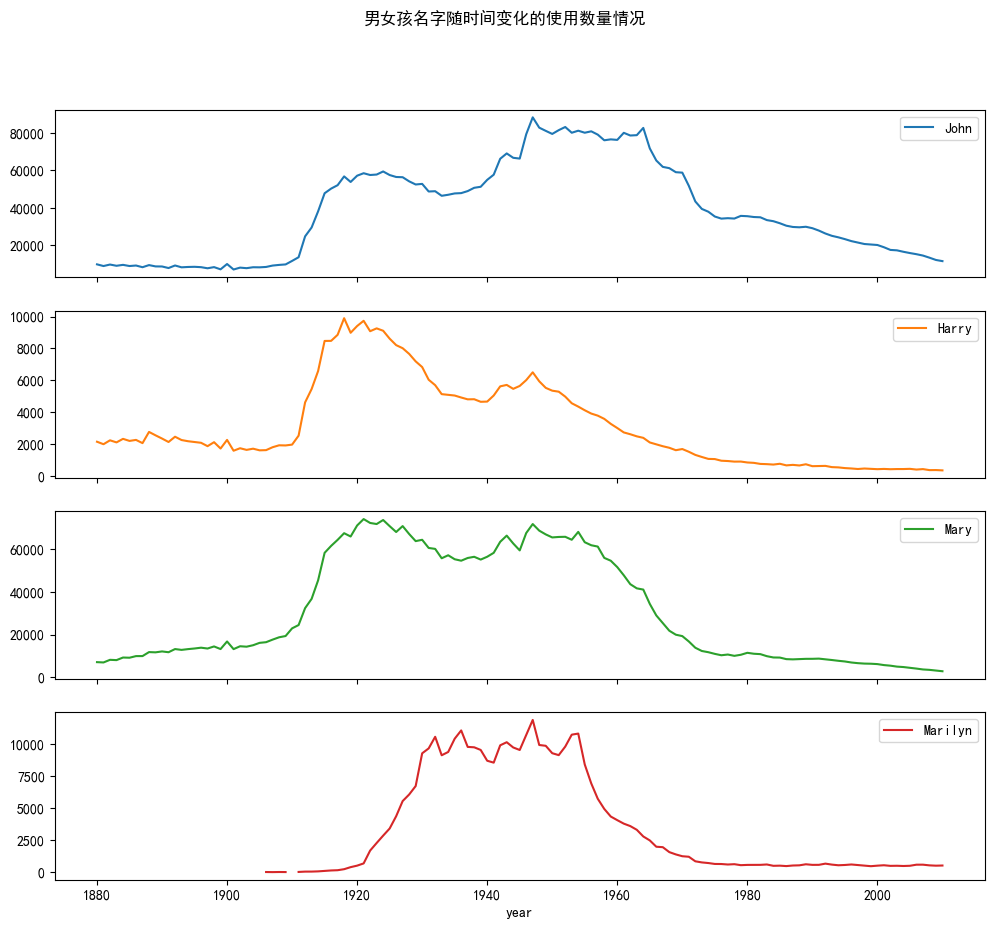

In [536]:
# 输出透视表中几个名字的每年所用的个数赋值给subset并作图
subset = total_births[["John", "Harry", "Mary", "Marilyn"]]
subset.plot(subplots=True, figsize=(12, 10),
            title="男女孩名字随时间变化的使用数量情况")

plt.show()

### 评估命名多样性的增长：
趋势下降的一种解释，是越来越少的父母愿意给小孩起常见的名字。这个假设可以从数据中得到验证。一个办法是计算最流行的1000个名字所占的出生比例，按年份和性别进行聚合并绘图：

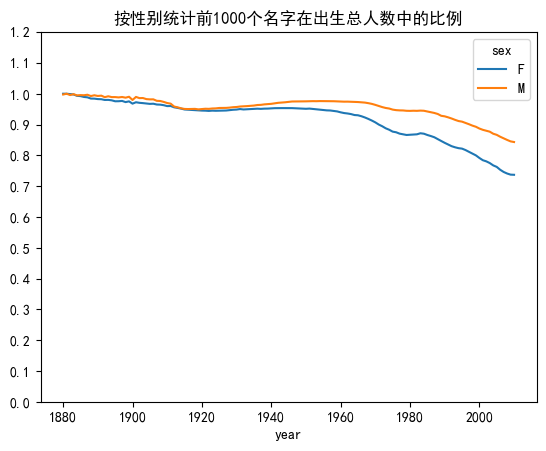

In [540]:
# 这个是根据前1000个最热门的名字在每年所占的比重，总和不超过1，明显呈现下降趋势，说明姓名的多样化
table = top1000.pivot_table("prop", index="year",
                            columns="sex", aggfunc="sum")

table.plot(title="按性别统计前1000个名字在出生总人数中的比例",
           yticks=np.linspace(0, 1.2, 13))  # y轴设置特定的刻度范围，从0到1.2中间包含13个数值

plt.show()

In [542]:
table.head()

sex,F,M
year,,
1880,1.000000,0.997375
1881,1.000000,1.000000
1882,0.998702,0.995646
1883,0.997596,0.998566
1884,0.993156,0.994539


**prop是婴儿姓名在所有出生婴儿所用姓名中占的比例，对prop进行透视，就是对prop数据进行操作，将prop数据值进行聚合，行索引为year，列索引是sex，对每年每个性别的prop求和**

从图中可以看出，名字的多样性确实出现了增长（前1000个名字的总比例降低）。另一个办法是计算占总出生人数前50%的不同名字的数量，按受欢迎程度从高到低排序。  



这个数字不太好计算。我们只考虑2010年的男孩名字：

In [546]:
# 选出2010年的所有数据
df = boys[boys["year"] == 2010]
df

,index,name,sex,births,year,prop
260877,1676644,Jacob,M,21875,2010,0.011523
260878,1676645,Ethan,M,17866,2010,0.009411
260879,1676646,Michael,M,17133,2010,0.009025
260880,1676647,Jayden,M,17030,2010,0.008971
260881,1676648,William,M,16870,2010,0.008887
...,...,...,...,...,...,...
261872,1677639,Camilo,M,194,2010,0.000102
261873,1677640,Destin,M,194,2010,0.000102
261874,1677641,Jaquan,M,194,2010,0.000102
261875,1677642,Jaydan,M,194,2010,0.000102


在对prop做降序排列之后，我们想知道需要多少最受欢迎的名字，才能使人数加起来达到50%。虽然编写for循环也能实现，但NumPy有一种更高效的向量方式。  

**先计算prop的累计和cumsum，然后通过searchsorted方法找出0.5应该被插入哪个位置才能保证不破坏顺序：**

In [549]:
prop_cumsum = df["prop"].sort_values(ascending=False).cumsum()  # 累加直到0.5表示一半人
prop_cumsum[:10]

260877    0.011523
260878    0.020934
260879    0.029959
260880    0.038930
260881    0.047817
260882    0.056579
260883    0.065155
260884    0.073414
260885    0.081528
260886    0.089621
Name: prop, dtype: float64

In [553]:
prop_cumsum.searchsorted(0.5)  # 累加到0.5在第117个数

116

由于数组索引1是从0开始的，因此我们要给这个结果加1，即最终结果为117。以1900年的数据来做比较，这个数字要小得多：

In [555]:
df = boys[boys.year == 1900]
in1900 = df.sort_values("prop", ascending=False).prop.cumsum()

in1900.searchsorted(0.5) + 1  # 2010 是117， 1900是26位，说明2010年比1900年姓名更丰富

25

现在就可以对各个年/性别组合执行这个操作了。按这两个字段进行groupby处理，然后通过apply用一个函数计算各分组的计数：

In [563]:
# 计算前50%的人大概用了多少个姓名
def get_quantile_count(group, q=0.5):
    group = group.sort_values("prop", ascending=False)
    return group.prop.cumsum().searchsorted(q) + 1

# 按year和sex分组，对前1000人取前50%使用的姓名个数
diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)

# 生成透视表，表中值是前 50% 人口使用的姓名个数，以 year 为行索引，sex 为列索引
diversity = diversity.unstack()

diversity.head()

C:\Users\杜苏苏\AppData\Local\Temp\ipykernel_17552\907875367.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  diversity = top1000.groupby(["year", "sex"]).apply(get_quantile_count)


sex,F,M
year,,
1880,38,14
1881,38,14
1882,38,15
1883,39,15
1884,39,16


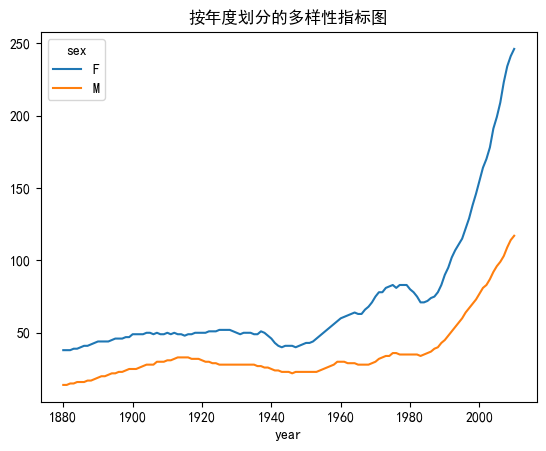

In [561]:
diversity.plot(title="按年度划分的多样性指标图")

plt.show()

从图中可以看出，女孩名字总是比男孩名字更多样，而且多样性还在变得越来越高。读
者可以自己分析一下具体是什么在驱动这个多样性，比如拼写形式的变化。

### 最后一个字母的变革  
2007年，一名婴儿姓名研究人员LauraWattenberg指出，近百年来，男孩名字的最后一个字母的分布发生了显著变化。为了了解具体情况，首先将全部出生数据按照年度、性别以及末字母进行聚合：

In [571]:
# 返回字符串的最后一个字母
def get_last_letter(x):
    return x[-1]

# 对names DF的"name"列应用函数，生成一个包含每个名字最后一个字母的Series
last_letters = names["name"].map(get_last_letter)

# 为last_letters这个Series命名为"last_letter"
last_letters.name = "last_letter"

# 创建透视表，表中的数据为出生人数，行索引为最后一个字母，列是年份和性别的组合
# 表格中的数据是基于名字最后一个字符进行分组后，对对应的出生人数（births 列）进行求和。
table = names.pivot_table("births", index=last_letters,
                          columns=["sex", "year"], aggfunc="sum")

table.head()

sex                F                                                        \
year            1880     1881     1882     1883     1884     1885     1886   
last_letter                                                                  
a            31446.0  31581.0  36536.0  38330.0  43680.0  45408.0  49100.0   
b                NaN      NaN      NaN      NaN      NaN      NaN      NaN   
c                NaN      NaN      5.0      5.0      NaN      NaN      NaN   
d              609.0    607.0    734.0    810.0    916.0    862.0   1007.0   
e            33378.0  34080.0  40399.0  41914.0  48089.0  49616.0  53884.0   

sex                                     ...         M                      \
year            1887     1888     1889  ...      2001      2002      2003   
last_letter                             ...                                 
a            48942.0  59442.0  58631.0  ...   39124.0   38815.0   37825.0   
b                NaN      NaN      NaN  ...   50950.0   49284.0   48065.0   
c                NaN      NaN      NaN  ...   27113.0   27238.0   27697.0   
d             1027.0   1298.0   1374.0  ...   60838.0   55829.0   53391.0   
e            54353.0  66750.0  66663.0  ...  145395.0  144651.0  144769.0   

sex                                                                      \
year             2004      2005      2006      2007      2008      2009   
last_letter                                                               
a             38650.0   36838.0   36156.0   34654.0   32901.0   31430.0   
b             45914.0   43144.0   42600.0   42123.0   39945.0   38862.0   
c             26778.0   26078.0   26635.0   26864.0   25318.0   24048.0   
d             51754.0   50670.0   51410.0   50595.0   47910.0   46172.0   
e            142098.0  141123.0  142999.0  143698.0  140966.0  135496.0   

sex                    
year             2010  
last_letter            
a             28438.0  
b             38859.0  
c             23125.0  
d             44398.0  
e            129012.0  

[5 rows x 262 columns]

In [573]:
# 选出具有代表性的三年，筛选出这三列
subtable = table.reindex(columns=[1910, 1960, 2010], level="year")
subtable.head()

sex                 F                            M                    
year             1910      1960      2010     1910      1960      2010
last_letter                                                           
a            108376.0  691247.0  670605.0    977.0    5204.0   28438.0
b                 NaN     694.0     450.0    411.0    3912.0   38859.0
c                 5.0      49.0     946.0    482.0   15476.0   23125.0
d              6750.0    3729.0    2607.0  22111.0  262112.0   44398.0
e            133569.0  435013.0  313833.0  28655.0  178823.0  129012.0

接下来，按出生总数对该表进行标准化处理，以便计算出一个新表格，其中包含每个字母结尾的性别占总出生人数的比例：

In [576]:
subtable.sum()

sex  year
F    1910     396416.0
     1960    2022062.0
     2010    1759010.0
M    1910     194198.0
     1960    2132588.0
     2010    1898382.0
dtype: float64

In [578]:
letter_prop = subtable / subtable.sum()
letter_prop

sex                 F                             M                    
year             1910      1960      2010      1910      1960      2010
last_letter                                                            
a            0.273390  0.341853  0.381240  0.005031  0.002440  0.014980
b                 NaN  0.000343  0.000256  0.002116  0.001834  0.020470
c            0.000013  0.000024  0.000538  0.002482  0.007257  0.012181
d            0.017028  0.001844  0.001482  0.113858  0.122908  0.023387
e            0.336941  0.215133  0.178415  0.147556  0.083853  0.067959
f                 NaN  0.000010  0.000055  0.000783  0.004325  0.001188
g            0.000144  0.000157  0.000374  0.002250  0.009488  0.001404
h            0.051529  0.036224  0.075852  0.045562  0.037907  0.051670
i            0.001526  0.039965  0.031734  0.000844  0.000603  0.022628
j                 NaN       NaN  0.000090       NaN       NaN  0.000769
k            0.000121  0.000156  0.000356  0.036581  0.049384  0.018541
l            0.043189  0.033867  0.026356  0.065016  0.104904  0.070367
m            0.001201  0.008613  0.002588  0.058044  0.033827  0.024657
n            0.079240  0.130687  0.140210  0.143415  0.152522  0.362771
o            0.001660  0.002439  0.001243  0.017065  0.012829  0.042681
p            0.000018  0.000023  0.000020  0.003172  0.005675  0.001269
q                 NaN       NaN  0.000030       NaN       NaN  0.000180
r            0.013390  0.006764  0.018025  0.064481  0.031034  0.087477
s            0.039042  0.012764  0.013332  0.130815  0.102730  0.065145
t            0.027438  0.015201  0.007830  0.072879  0.065655  0.022861
u            0.000684  0.000574  0.000417  0.000124  0.000057  0.001221
v                 NaN  0.000060  0.000117  0.000113  0.000037  0.001434
w            0.000020  0.000031  0.001182  0.006329  0.007711  0.016148
x            0.000015  0.000037  0.000727  0.003965  0.001851  0.008614
y            0.110972  0.152569  0.116828  0.077349  0.160987  0.058168
z            0.002439  0.000659  0.000704  0.000170  0.000184  0.001831

有了这个字母比例数据之后，就可以生成一张各年度各性别的柱状图了

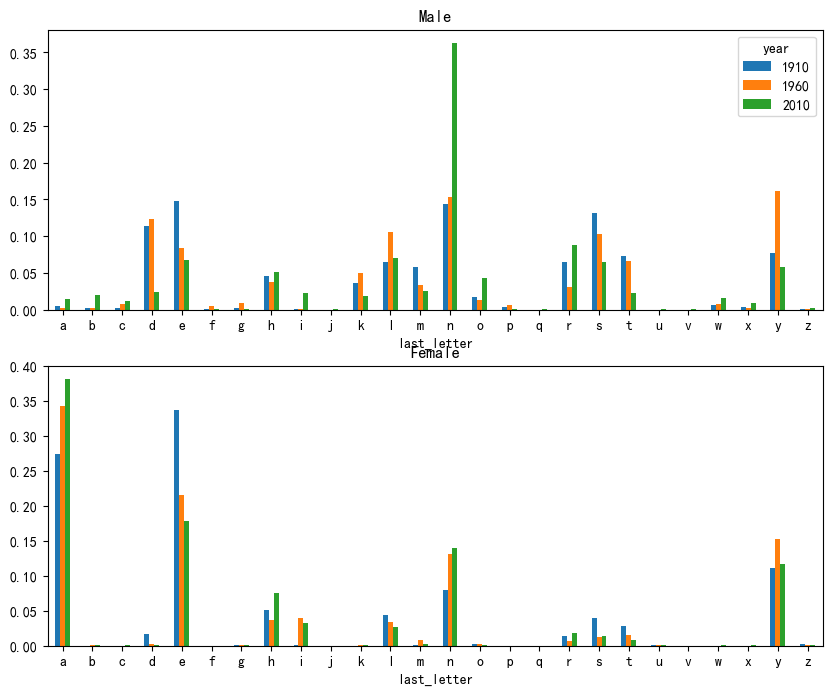

In [591]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plt.title("男孩女孩名字中各个末字母的比例")

# "M"男性数据，rot是x轴旋转的角度，axed[0]选取第一个子图，标题
letter_prop["M"].plot(kind="bar", rot=0, ax=axes[0], title="Male")
letter_prop["F"].plot(kind="bar", rot=0, ax=axes[1], title="Female",
                      legend=False)


plt.tight_layout()
plt.show()

可以看出，从20世纪60年代开始，以字母“n”结尾的男孩名字出现了显著增长。回到之前创建的完整表格，按年度和性别对其进行标准化处理，并在男孩名字中选取几个字母的子集，最后进行转置以便将各列转换成时间序列：

In [623]:
table.head()

sex,F,M
year,,
1880,0.091954,0.908046
1881,0.106796,0.893204
1882,0.065693,0.934307
1883,0.053030,0.946970
1884,0.107143,0.892857


In [594]:
letter_prop = table / table.sum()  # 名字最后一个字母在每个年份和性别组合下的比例。
dny_ts = letter_prop.loc[["d", "n", "y"], "M"].T
dny_ts.head()

last_letter,d,n,y
year,,,
1880,0.083055,0.153213,0.075760
1881,0.083247,0.153214,0.077451
1882,0.085340,0.149560,0.077537
1883,0.084066,0.151646,0.079144
1884,0.086120,0.149915,0.080405


有了这个时间序列的DataFrame之后，就可以通过其plot方法绘制趋势图了

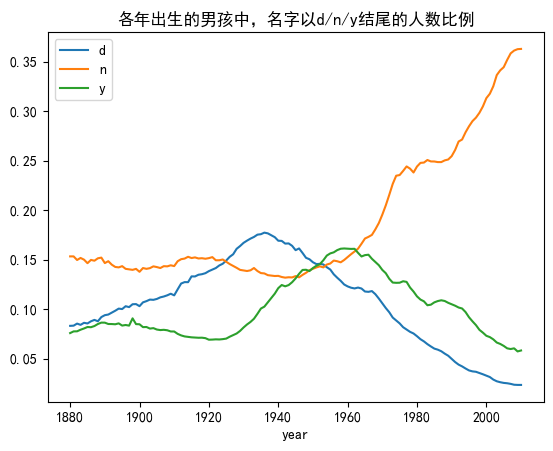

In [603]:
dny_ts.plot()

plt.title("各年出生的男孩中，名字以d/n/y结尾的人数比例")

plt.legend()

plt.show()

**男孩名字变成女孩的名字(以及相反的情况)**  
另一个有趣的趋势就是早年流行于样本中某个性别的名字近年来"变性了"。  
如：Lesley或Leslic这两个名字。  
回到top1000的DF，通过计算找出其中以"Lesl"开头的名字或列表：头

In [610]:
all_names = pd.Series(top1000["name"].unique())
lesley_like = all_names[all_names.str.contains("Lesl")]
lesley_like

632     Leslie
2294    Lesley
4262    Leslee
4728     Lesli
6103     Lesly
dtype: object

利用这个结果过滤其他名字，并按名字分组计算出生总数以查看相对频率：

In [613]:
filtered = top1000[top1000["name"].isin(lesley_like)]
filtered.groupby("name")["births"].sum()

name
Leslee      1082
Lesley     35022
Lesli        929
Leslie    370429
Lesly      10067
Name: births, dtype: int64

按性别和年度进行聚合，并按年度进行标准化处理

In [616]:
table = filtered.pivot_table("births", index="year",
                             columns="sex", aggfunc="sum")

table = table.div(table.sum(axis="columns"), axis="index")

table.tail()

sex,F,M
year,,
2006,1.0,NaN
2007,1.0,NaN
2008,1.0,NaN
2009,1.0,NaN
2010,1.0,NaN


最后，就可以按性别绘制一张年度曲线图了

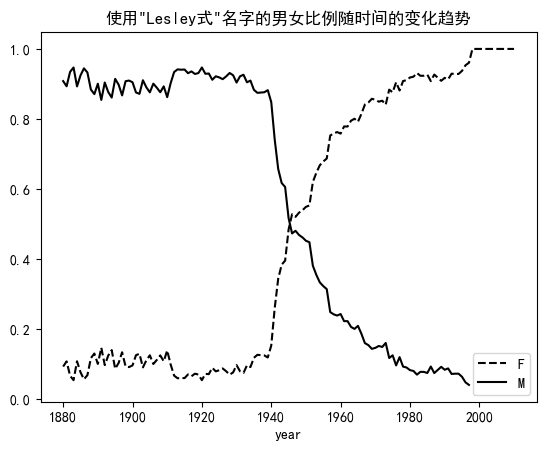

In [621]:
table.plot(style={"M": "k-", "F": "k--"})

plt.title('使用"Lesley式"名字的男女比例随时间的变化趋势')

plt.legend()

plt.show()